In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

Description de l'ensemble de données
Vue d'

Les données ont été divisées en deux groupes:

    Ensemble d'entraînement (train.csv)
    Ensemble d'essai (test.csv)

L'ensemble de formation doit être utilisé pour construire vos modèles d'apprentissage automatique. Pour l'ensemble de formation, nous fournissons le résultat (également connu sous le nom de « vérité de base ») pour chaque passager. Votre modèle sera basé sur des «caractéristiques» comme le sexe et la classe des passagers. Vous pouvez également utiliser l'ingénierie des fonctionnalités pour créer de nouvelles fonctionnalités.

L'ensemble de tests doit être utilisé pour voir dans quelle mesure votre modèle fonctionne sur des données invisibles. Pour l'essai, nous ne fournissons pas la vérité au sol pour chaque passager. Il est de votre devoir de prédire ces résultats. Pour chaque passager de l'ensemble de test, utilisez le modèle que vous avez formé pour prédire s'il a survécu ou non à l'enfoncement du Titanic.

Nous incluons également gender-submission.csv, un ensemble de prédictions qui supposent que toutes les femmes survivent, comme exemple de ce à quoi devrait ressembler un dossier de soumission.
Dictionnaire de données
Variable	Définition	Principale
survie 	Survie 	0 Non, 1 Oui
pclasse 	Classe de billets 	1 1er, 2 et 2e, 3e, 3e
sexe 	Sexe
Age 	Age en années
sibsp 	Nombre de frères et sœurs/conjoints à bord du Titanic
parch 	Nombre de parents/enfants à bord du Titanic
billet 	Numéro du billet
Tarifs 	Tarifs passagers
cabine 	Numéro de cabine
embarqué 	Port d'embarquement 	C - Cherbourg, Q et Queenstown, S et Southampton
Notes à variation

pclasse: Un indicateur du statut socio-économique (CUE)
1er et supérieur
2ème - Moyenne
3e - . . . .

âge: L'âge est fractionnaire si moins de 1. Si l'âge est estimé, est-il sous la forme de xx.5

sibsp: L'ensemble de données définit les relations familiales de cette manière...
Frère et frère, sœur, beau-frère, belle-mère
Époux - mari, femme (les maîtresses et les fiancés ont été ignorés)

parch: L'ensemble de données définit les relations familiales de cette manière...
Parent et mère, père
Enfant et fille, fils, belle-fille, beau-fils
Certains enfants n'ont voyagé qu'avec une nounou, parcz 0 pour eux.


In [2]:
df = pd.read_csv('train.csv')

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

In [5]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [18]:
df['Age'].fillna(df['Age'].median(), inplace=True)

<ipython-input-18-6cf6b1ae0c4f>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


In [20]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Age,0
SibSp,0
Parch,0
Fare,0
FamilySize,0
IsAlone,0
Sex_male,0
Embarked_Q,0


In [21]:
df['FamilySize'] = df['SibSp'] + df['Parch']

In [22]:
df['IsAlone'] = 0
df.loc[df['FamilySize'] == 0, 'IsAlone'] = 1

In [24]:
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,1,0,True,False,True
1,1,1,38.0,1,0,71.2833,1,0,False,False,False
2,1,3,26.0,0,0,7.9250,0,1,False,False,True
3,1,1,35.0,1,0,53.1000,1,0,False,False,True
4,0,3,35.0,0,0,8.0500,0,1,True,False,True


<Axes: xlabel='Survived', ylabel='count'>

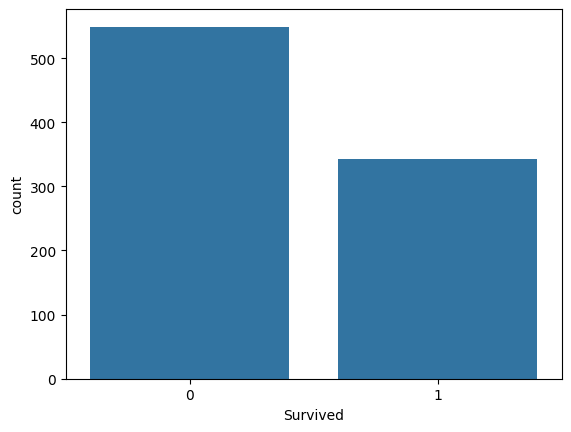

In [25]:
sns.countplot(x='Survived', data=df)

In [26]:
from sklearn.model_selection import train_test_split

In [27]:
X = df.drop('Survived', axis=1)
y = df['Survived']

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=101)

In [29]:
from sklearn.preprocessing import StandardScaler

In [30]:
scale = StandardScaler()

In [31]:
scale_X_train = scale.fit_transform(X_train)
scale_X_test = scale.transform(X_test)

In [32]:
from sklearn.linear_model import LogisticRegression

In [33]:
log_model = LogisticRegression()

In [34]:
log_model.fit(scale_X_train, y_train)

LogisticRegression()

In [35]:
log_pred = log_model.predict(scale_X_test)

In [36]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [37]:
confusion_matrix(y_test, log_pred)

array([[135,  19],
       [ 38,  76]])

In [38]:
print(classification_report(y_test, log_pred))

              precision    recall  f1-score   support

           0       0.78      0.88      0.83       154
           1       0.80      0.67      0.73       114

    accuracy                           0.79       268
   macro avg       0.79      0.77      0.78       268
weighted avg       0.79      0.79      0.78       268



Grid

In [39]:
from sklearn.model_selection import GridSearchCV

In [40]:
param_grid_log = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear']
}

In [41]:
grid = GridSearchCV(log_model, param_grid_log)

In [42]:
grid.fit(scale_X_train, y_train)

GridSearchCV(estimator=LogisticRegression(),
             param_grid={'C': [0.01, 0.1, 1, 10, 100],
                         'solver': ['lbfgs', 'liblinear']})

In [43]:
grid.best_params_

{'C': 0.1, 'solver': 'lbfgs'}

In [44]:
grid.best_estimator_

LogisticRegression(C=0.1)

In [45]:
pred_grid = grid.predict(scale_X_test)

In [46]:
confusion_matrix(y_test, pred_grid)

array([[135,  19],
       [ 39,  75]])

In [47]:
print(classification_report(y_test, pred_grid))

              precision    recall  f1-score   support

           0       0.78      0.88      0.82       154
           1       0.80      0.66      0.72       114

    accuracy                           0.78       268
   macro avg       0.79      0.77      0.77       268
weighted avg       0.79      0.78      0.78       268



SVM

In [48]:
from sklearn.svm import SVC

In [49]:
svm = SVC()

In [66]:
param_grid_svm = {'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto'],
    'degree': [2, 3, 4],
    'class_weight': ['balanced', None]
}

In [67]:
grid_svm = GridSearchCV(svm, param_grid_svm)

In [68]:
grid_svm.fit(scale_X_train, y_train)

GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100],
                         'class_weight': ['balanced', None],
                         'degree': [2, 3, 4], 'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'rbf', 'poly']})

In [69]:
grid_svm.best_params_

{'C': 1, 'class_weight': None, 'degree': 2, 'gamma': 'scale', 'kernel': 'rbf'}

In [70]:
pred_grid_svm = grid_svm.predict(scale_X_test)

In [71]:
confusion_matrix(y_test, pred_grid_svm)

array([[138,  16],
       [ 35,  79]])

In [72]:
print(classification_report(y_test, pred_grid_svm))

              precision    recall  f1-score   support

           0       0.80      0.90      0.84       154
           1       0.83      0.69      0.76       114

    accuracy                           0.81       268
   macro avg       0.81      0.79      0.80       268
weighted avg       0.81      0.81      0.81       268



In [73]:
from sklearn.ensemble import RandomForestClassifier

In [58]:
random_forest = RandomForestClassifier()

In [59]:
param_grid_random_forest = {
    'n_estimators': [64, 100, 120, 200],
    'max_features': [2, 4, 6, 8, 10],
    'bootstrap': [True, False],
    'oob_score': [True, False]
}


In [60]:
grid_random_forest = GridSearchCV(random_forest, param_grid_random_forest)

In [61]:
grid_random_forest.fit(scale_X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
100 fits failed out of a total of 400.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
100 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/ensemble/_forest.py", line 448, in fit
    raise ValueError("Out of b

GridSearchCV(estimator=RandomForestClassifier(),
             param_grid={'bootstrap': [True, False],
                         'max_features': [2, 4, 6, 8, 10],
                         'n_estimators': [64, 100, 120, 200],
                         'oob_score': [True, False]})

In [62]:
grid_random_forest.best_params_

{'bootstrap': True, 'max_features': 2, 'n_estimators': 64, 'oob_score': True}

In [63]:
pred_grid_random_forest = grid_random_forest.predict(scale_X_test)

In [64]:
confusion_matrix(y_test, pred_grid_random_forest)

array([[134,  20],
       [ 38,  76]])

In [65]:
print(classification_report(y_test, pred_grid_random_forest))

              precision    recall  f1-score   support

           0       0.78      0.87      0.82       154
           1       0.79      0.67      0.72       114

    accuracy                           0.78       268
   macro avg       0.79      0.77      0.77       268
weighted avg       0.78      0.78      0.78       268



In [86]:
random_passenger = [[3,	26.0,	0,	0,	7.92,	0,	1,	0,	0,	1]]

In [87]:
columns = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_female', 'Sex_male', 'Embarked_C', 'Embarked_Q', 'Embarked_S']

In [88]:
test = pd.DataFrame(random_passenger, columns=columns)

In [89]:
grid_svm.predict(test)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


array([0])

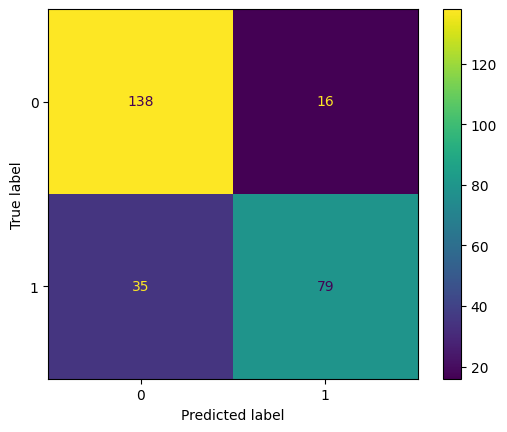

In [90]:
ConfusionMatrixDisplay.from_estimator(grid_svm, scale_X_test, y_test)

Autre donnée carrément à analyser

In [92]:
url = 'https://raw.githubusercontent.com'

In [96]:
pd.read(url)

AttributeError: module 'pandas' has no attribute 'read'